In [ ]:
# E-Commerce Profitability Analysis

Business Problem:
An e-commerce company has high sales but inconsistent profits. Management wants to understand:
- What drives revenue
- Why profitability is low
- Which customers/products contribute most
- How to improve business performance


The Dataset used in this Business Problem is of  orders
Dataset:
Table: orders
Columns:
order_id, customer_id, order_date, region, category, product, sales, quantity, discount, profit


Project Sections and Questions

SECTION 1: Data Cleaning (Python)

Q1) Convert order_date to datetime

In [ ]:
import pandas as pd
df=pd.read_csv("ecoms.csv")
print(df) # Given dataframe
df["order_date"]=pd.to_datetime(df["order_date"])
print(df.dtypes) # Datatypes of columns


     order_id  customer_id  order_date region     category     product  \
0           1       1004.0  2023-02-16  North  Electronics      Laptop   
1           2       1558.0         NaN   East    Furniture        Sofa   
2           3       1118.0         NaN    NaN     Clothing      Jacket   
3           4          NaN         NaN   East    Furniture        Sofa   
4           5       1310.0  2023-07-04   East  Electronics  Headphones   
..        ...          ...         ...    ...          ...         ...   
795       796          NaN         NaN  North    Furniture        Sofa   
796       797          NaN  2023-09-16   West     Clothing       Jeans   
797       798       1315.0         NaN   West          NaN      Tablet   
798       799          NaN  2023-10-25    NaN  Electronics      Tablet   
799       800          NaN  2023-02-27   West    Furniture       Chair   

       sales  quantity  discount   profit  
0    13850.0       2.0       NaN      0.0  
1     3981.0       NaN 

Q2) Check missing values

In [ ]:
import pandas as pd
df=pd.read_csv("ecoms.csv")
print(df.isnull()) # Null value analysis of dataframe
print(df.isnull().sum()) # Column wise analysis of Null Values
print(df.isnull().sum().sum()) # Total Sum of Missing Values


     order_id  customer_id  order_date  region  category  product  sales  \
0       False        False       False   False     False    False  False   
1       False        False        True   False     False    False  False   
2       False        False        True    True     False    False  False   
3       False         True        True   False     False    False  False   
4       False        False       False   False     False    False  False   
..        ...          ...         ...     ...       ...      ...    ...   
795     False         True        True   False     False    False  False   
796     False         True       False   False     False    False   True   
797     False        False        True   False      True    False  False   
798     False         True       False    True     False    False   True   
799     False         True       False   False     False    False  False   

     quantity  discount  profit  
0       False      True   False  
1        True     F

There are total 1637 Missing Values in ecommerce dataframe.The Customer_id has 418,order_date 400,region 63,category 73,product 57,sales 82,quantity 404,discount 84 and profit 56 missing values

Q3) Remove duplicates records

In [ ]:
#3
import pandas as pd
df=pd.read_csv("ecoms.csv")
print(df.duplicated().any()) # Checking the duplicate records in columns
print(df.duplicated().sum()) # Total Sum of Duplicated values
df.drop_duplicates(inplace=True) # Removal of duplicates

False
0


There are no duplicate values in all columns

Q4) Validate data types of all columns

In [ ]:
#4
print(df.columns) # Columns of dataframe
print(df.dtypes) # Validate the datatypes of all columns

Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')
order_id         int64
customer_id    float64
order_date      object
region          object
category        object
product         object
sales          float64
quantity       float64
discount       float64
profit         float64
dtype: object


The data type of order_id is integer.Customer_id,sales,quantity,discount and profit is float64.Datatype of order_date,region,category and product is object

Section 2
Exploratory Data Analysis(Python)

Q5) What is total sales and total profit

In [ ]:
#5
print(df.columns) # Columns of dataframe
total_sales=df["sales"].sum()
total_profit=df["profit"].sum()
print(f"The total sales of dataframe is : {total_sales}")
print(f"The total profit of dataframe is : {total_profit}")

Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')
The total sales of dataframe is : 25753804.0
The total profit of dataframe is : 4773453.0


Q6) Sales distribution by region

Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')
  region      sales
0   East  5541111.0
1  North  5521628.0
2  South  6473762.0
3   West  6457922.0


<BarContainer object of 4 artists>

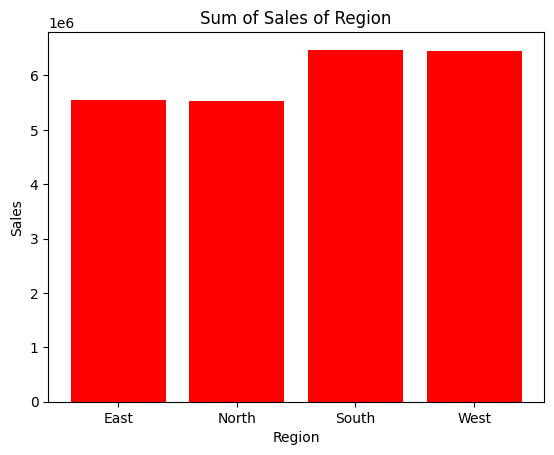

In [ ]:
import matplotlib.pyplot as plt
print(df.columns) # Columns of dataframe
df1=df.groupby("region")["sales"].sum().reset_index()
print(df1) # Sales distribution by region
x=df1["region"]
y=df1["sales"]
plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Sum of Sales of Region")
plt.bar(x,y,color="red")


The Region of Maximum Sales is South with sales of 6473762.0

Q7)Sales distribution by category

Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')
      category      sales
0     Clothing  8863244.0
1  Electronics  7717275.0
2    Furniture  6881543.0


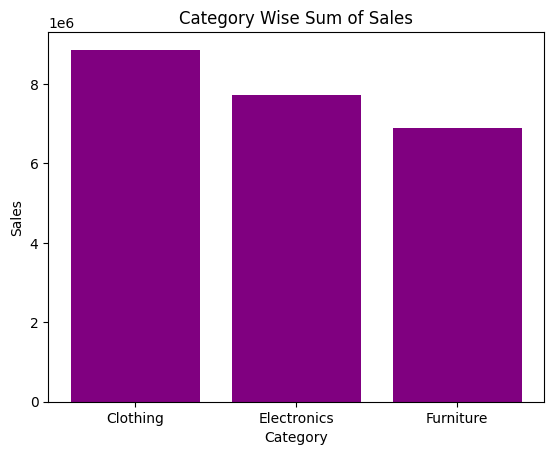

In [ ]:
#7
import matplotlib.pyplot as plt
print(df.columns) # Columns of dataframe
df1=df.groupby("category")["sales"].sum().reset_index()
print(df1) # Sales distribution by category
x=df1["category"]
y=df1["sales"]
plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Category Wise Sum of Sales")
plt.bar(x,y,color="purple")
plt.show()

The Maximum Sales Category is Clothing with Sales of 8863244.0

Q8)Monthly Sales Trend

In [ ]:
#8
df["order_date"]=pd.to_datetime(df["order_date"])
df["month"]=df["order_date"].dt.month
df["year"]=df["order_date"].dt.year
print(df.columns) # Columns of dataframe
monthly_sales=df.groupby(["year","month"])["sales"].sum().reset_index()
print(monthly_sales) # Monthly Sales trend



Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit', 'month', 'year'],
      dtype='object')
      year  month      sales
0   2023.0    1.0  1203976.0
1   2023.0    2.0  1111242.0
2   2023.0    3.0  1082769.0
3   2023.0    4.0   839409.0
4   2023.0    5.0  1339066.0
5   2023.0    6.0  1207651.0
6   2023.0    7.0   890866.0
7   2023.0    8.0  1417902.0
8   2023.0    9.0   677544.0
9   2023.0   10.0   739101.0
10  2023.0   11.0   871657.0
11  2023.0   12.0  1628049.0
12  2024.0    1.0    60234.0


<Axes: xlabel='month', ylabel='sales'>

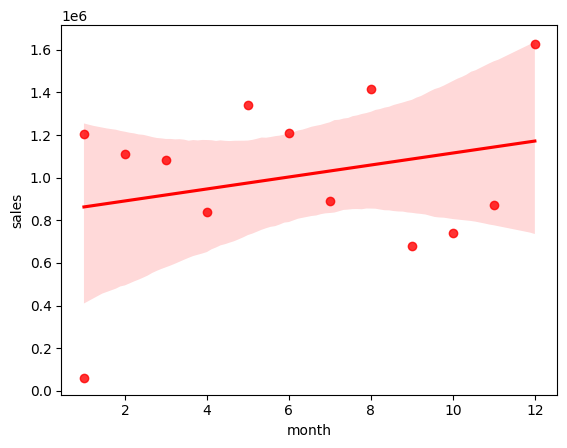

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.regplot(x="month",y="sales",data=monthly_sales,color="red")


The sales values are declining for the upcoming months.Hence,there is a negative trend line of sales value of upcoming months

Section 3
Profitability Analysis

Q9)Which region has highest profit margin?

In [ ]:
#9
df["profit_margin"]=df["profit"]/df["sales"]
print(df.columns) # Columns of dataframe
df2=df.groupby("region")["profit_margin"].mean().reset_index()
df2.sort_values(by="profit_margin",ascending=False,inplace=True)
print(df2.head(1))

Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit', 'month', 'year',
       'profit_margin'],
      dtype='object')
  region  profit_margin
2  South       0.179981


The region with highest profit margin is South with value of   0.179981

Q10) Which category is most profitable?

In [ ]:
#10
print(df.columns) # Columns of dataframe
c1=df.groupby("category")["profit"].sum().reset_index()
c1.sort_values(by="profit",ascending=False,inplace=True)
print(c1.head(1)) # Most Profitable Category

Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit', 'month', 'year',
       'profit_margin'],
      dtype='object')
      category     profit
1  Electronics  1498228.0


<BarContainer object of 3 artists>

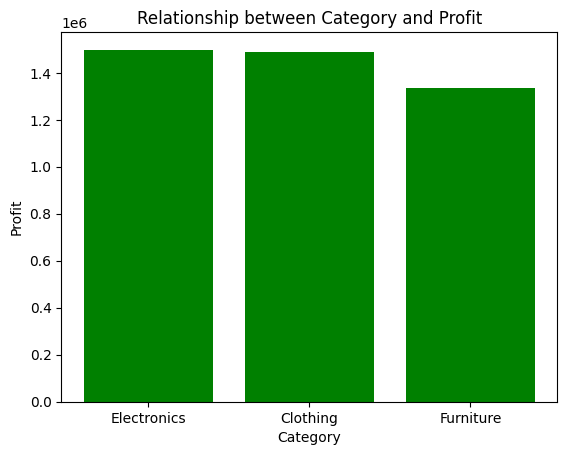

In [ ]:
import matplotlib.pyplot as plt
x=c1["category"]
y=c1["profit"]
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Relationship between Category and Profit")
plt.bar(x,y,color="green")

The most profitable Category is Electronics with total profit of  1498228.0

Q11) Which Products are loss making?

In [ ]:
#11
print(df.columns)
df3=df.groupby("product")["profit"].sum().reset_index()
df3.sort_values(by="profit",ascending=True,inplace=True)
print(df3) # Profit Values of Various Products


Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit', 'month', 'year',
       'profit_margin'],
      dtype='object')
      product    profit
4      Laptop  318582.0
1  Headphones  375335.0
3       Jeans  395567.0
5      Mobile  427623.0
8       Table  431532.0
0       Chair  433622.0
9      Tablet  434907.0
2      Jacket  464920.0
7        Sofa  537099.0
6       Shirt  629841.0


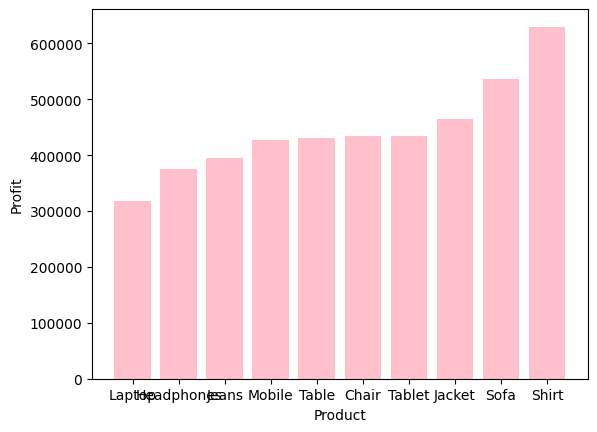

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
x=df3["product"]
y=df3["profit"]
plt.bar(x,y,color="pink")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.show()

From,the above mentioned bar graph and grouped dataframe,there is no loss making products in Products Columns.The profits of Shirt,Sofa and Jacket are comparatively high as compare to Laptop,Headphones and Jeans but the profit amounts of all items in Products are positive.There is no such product where profit amount is less than 0

Q12) Profit Margin Calculation(profit/sales)

In [ ]:
#12
print(df.columns) # Columns of dataframe
print(df["profit_margin"]) # Profit Margin Values (Profit/Sales)


Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit', 'month', 'year',
       'profit_margin'],
      dtype='object')
0      0.000000
1      0.299925
2      0.099985
3      0.300000
4      0.199987
         ...   
795    0.099956
796         NaN
797    0.149995
798         NaN
799    0.000000
Name: profit_margin, Length: 800, dtype: float64


Section 4
Discount Impact Analysis

Q13)Does higher discount reduce profit?

In [ ]:
print(df.columns)
d1=df[["discount","profit"]]
d1.dropna(inplace=True)
print(d1) # Dataframe of discount and profit after dropping the null values


Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit', 'month', 'year',
       'profit_margin'],
      dtype='object')
     discount   profit
1         0.0   1194.0
2        20.0   4738.0
3         0.0   7914.0
4        10.0   9544.0
5        10.0  11420.0
..        ...      ...
793       0.0  14267.0
795      20.0   2278.0
797      15.0   9562.0
798       0.0  18387.0
799      30.0      0.0

[666 rows x 2 columns]


/tmp/ipykernel_12191/534544712.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d1.dropna(inplace=True)


In [ ]:
d3=d1[d1["discount"]==30]
print(d3)

     discount  profit
17       30.0     0.0
21       30.0     0.0
29       30.0     0.0
33       30.0     0.0
40       30.0     0.0
..        ...     ...
746      30.0     0.0
766      30.0     0.0
776      30.0     0.0
786      30.0     0.0
799      30.0     0.0

[100 rows x 2 columns]


In [ ]:
d4=d1[d1["discount"]==0]
print(d4)


     discount   profit
1         0.0   1194.0
3         0.0   7914.0
30        0.0  19067.0
31        0.0  15290.0
43        0.0   3008.0
..        ...      ...
749       0.0   1323.0
752       0.0   3705.0
760       0.0  17019.0
793       0.0  14267.0
798       0.0  18387.0

[116 rows x 2 columns]


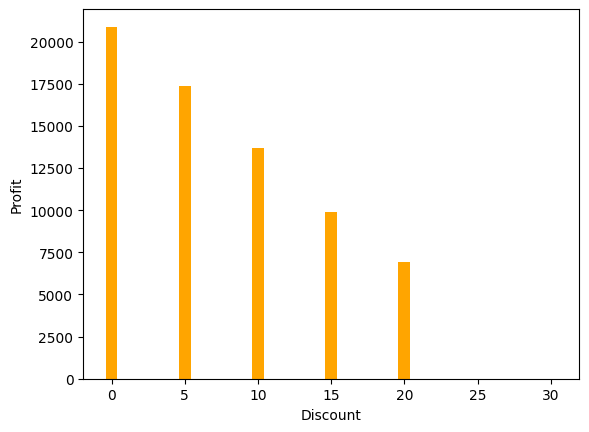

In [ ]:
import matplotlib.pyplot as plt
x=d1["discount"]
y=d1["profit"]
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.bar(x,y,color="orange")
plt.show()

In [ ]:
d1[["discount","profit"]].corr()

,discount,profit
discount,1.000000,-0.689062
profit,-0.689062,1.000000


Yes,Higher discount reduces the profit.From the above mentioned bar graph and correlation matrix,it is clear that there is a slightly negative correlation between discount and profit.When there is no discount or profit value is 0 then profit values are in the range of 1194 to 2000,but when discount value is 30 then there is zero profit.Hence,ecommerce company can focus on the moderate discount value in order to increase the profit.There is a negative correlation value of -0.689062 between discount and profit

Q14) Compare profit across discount ranges

Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit', 'month', 'year',
       'profit_margin'],
      dtype='object')


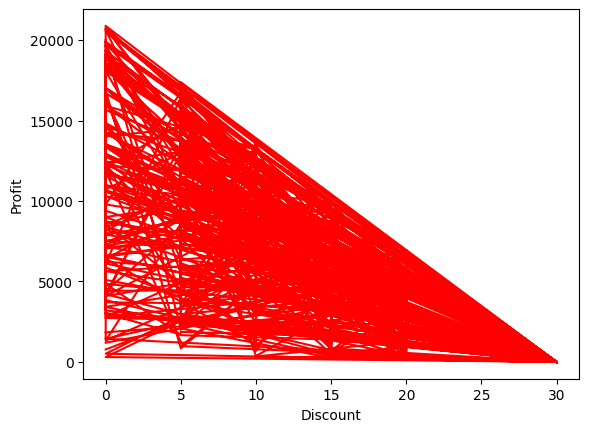

In [ ]:
#14
import matplotlib.pyplot as plt
import seaborn as sns
print(df.columns)
x=df["discount"]
y=df["profit"]
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.plot(x,y,color="red")
plt.show()

The discount values are in the range from 0 to 30 while profit values are in the range from 0 to 20000. When there is no discount the profit is maximum,and at the highest discount 30 the profit is minimum.The Profit is almost moderate when the discount values are in the range from 7 to 10

<Axes: xlabel='discount', ylabel='profit'>

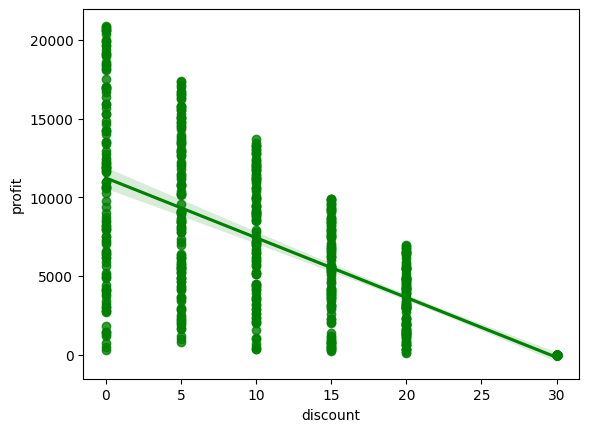

In [ ]:
import seaborn as sns
sns.regplot(x="discount",y="profit",data=df,color="green")


From,the above mentioned regression plot it is clear that profit is declining when discount is increasing.There is a negative trendline of profit values with increasing discount amounts

Q15)What is optimal discount range

In [ ]:
#15
print(df.columns) # Columns of dataframe
df["discount"].mean()

Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit', 'month', 'year',
       'profit_margin'],
      dtype='object')


np.float64(12.758379888268156)

/tmp/ipykernel_3367/2124357083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='discount', y='profit', data=optimal_discount, palette='viridis')


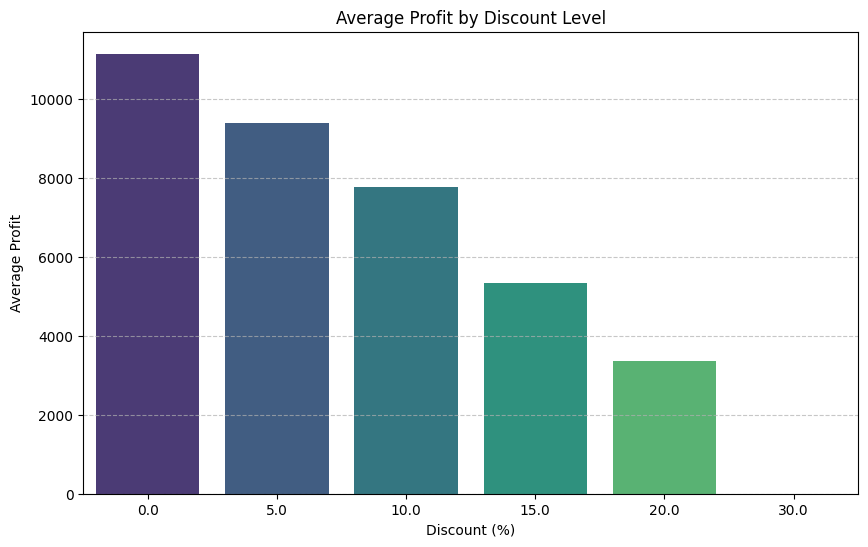

,discount,profit
0,0.0,11145.310345
1,5.0,9387.507937
2,10.0,7769.649123
3,15.0,5330.811321
4,20.0,3373.817308
5,30.0,0.000000


In [ ]:
# Group by discount to see average profit
optimal_discount = df.groupby('discount')['profit'].mean().reset_index()

# Visualize the optimal range
plt.figure(figsize=(10, 6))
sns.barplot(x='discount', y='profit', data=optimal_discount, palette='viridis')
plt.title('Average Profit by Discount Level')
plt.xlabel('Discount (%)')
plt.ylabel('Average Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display the numerical values
display(optimal_discount.sort_values(by='profit', ascending=False))

In [ ]:
print(df.columns) # Columns of dataframe
optimal_discount=df.groupby("discount")["profit"].mean().reset_index()
print(optimal_discount) # Optimal discount range

Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')
   discount        profit
0       0.0  11145.310345
1       5.0   9387.507937
2      10.0   7769.649123
3      15.0   5330.811321
4      20.0   3373.817308
5      30.0      0.000000


Section 7
Statistical Analysis

Q16) Mean vs Median

In [ ]:
#16
import pandas as pd
df=pd.read_csv("ecoms.csv")
print(df) # Given dataframe
print(df.columns) # Columns of dataframe
mean=df["sales"].mean()
median=df["sales"].median()
print(f"The mean value of sales column is : {mean}")
print(f"The median value of sales column is : {median}")


     order_id  customer_id  order_date region     category     product  \
0           1       1004.0  2023-02-16  North  Electronics      Laptop   
1           2       1558.0         NaN   East    Furniture        Sofa   
2           3       1118.0         NaN    NaN     Clothing      Jacket   
3           4          NaN         NaN   East    Furniture        Sofa   
4           5       1310.0  2023-07-04   East  Electronics  Headphones   
..        ...          ...         ...    ...          ...         ...   
795       796          NaN         NaN  North    Furniture        Sofa   
796       797          NaN  2023-09-16   West     Clothing       Jeans   
797       798       1315.0         NaN   West          NaN      Tablet   
798       799          NaN  2023-10-25    NaN  Electronics      Tablet   
799       800          NaN  2023-02-27   West    Furniture       Chair   

       sales  quantity  discount   profit  
0    13850.0       2.0       NaN      0.0  
1     3981.0       NaN 

The median of sales is greater than mean,it means that distribution is negatively skewed

Q17) Outliers using IQR

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) of sales
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['sales'] < lower_bound) | (df['sales'] > upper_bound)]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of outliers detected: {len(outliers)}")

if len(outliers) > 0:
    display(outliers)

Q1: 19436.0
Q3: 52928.0
IQR: 33492.0
Lower Bound: -30802.0
Upper Bound: 103166.0
Number of outliers detected: 0


Q18)Correlation (discount vs profit, quantity vs sales)

In [ ]:
#18
import pandas as pd
df=pd.read_csv("ecoms.csv")

d1=df[["discount","profit"]].corr()
d2=df[["quantity","sales"]].corr()

print(d1) # Correlation matrix of discount vs profit
print(d2) # Correlation matrix of quantity vs sales

          discount    profit
discount  1.000000 -0.689062
profit   -0.689062  1.000000
          quantity     sales
quantity  1.000000  0.027169
sales     0.027169  1.000000


<Axes: >

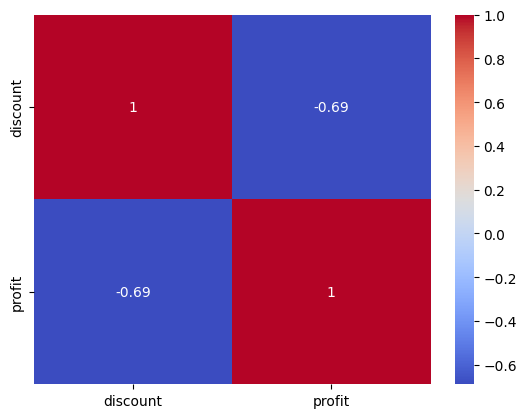

In [ ]:
import seaborn as sns
sns.heatmap(d1,annot=True,cmap="coolwarm")

<Axes: >

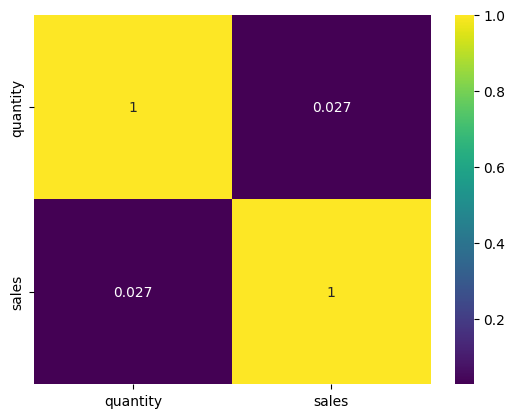

In [ ]:
import seaborn as sns
sns.heatmap(d2,annot=True,cmap="viridis")

From the above mentioned correlation matrix and heatmap,it is clear that there is a weak positive correlation between quantity and sales of 0.027 and there is a strong negative correlation  between discount and sales of -0.69

Section 8
Visualization

Q19) Draw the heatmap of Correlation Matrix

In [ ]:
#19
import pandas as pd
df=pd.read_csv("ecoms.csv")
d1=df[["order_id","customer_id","sales","quantity","discount","profit"]]
print(d1.corr()) # Correlation matrix of ecommerce dataframe


             order_id  customer_id     sales  quantity  discount    profit
order_id     1.000000     0.011095  0.062706 -0.034620 -0.072706  0.074326
customer_id  0.011095     1.000000  0.046823  0.000350  0.037463  0.003234
sales        0.062706     0.046823  1.000000  0.027169 -0.110153  0.709537
quantity    -0.034620     0.000350  0.027169  1.000000  0.009874 -0.000548
discount    -0.072706     0.037463 -0.110153  0.009874  1.000000 -0.689062
profit       0.074326     0.003234  0.709537 -0.000548 -0.689062  1.000000


<Axes: >

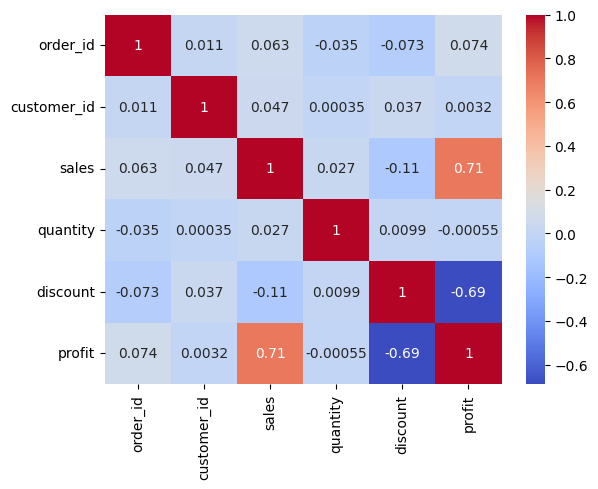

In [ ]:
import seaborn as sns
sns.heatmap(d1.corr(),annot=True,cmap="coolwarm") # Heatmap of correlation matrix

Q20) Create Boxplot

Index(['order_id', 'customer_id', 'order_date', 'region', 'category',
       'product', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


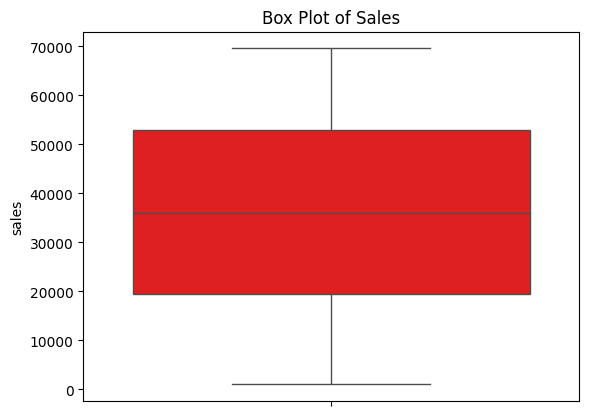

In [ ]:
#20
import seaborn as sns
print(df.columns) # Columns of dataframe
sns.boxplot(df["sales"],color="red") # Box Plot View of Sales columns
plt.title("Box Plot of Sales")
plt.show()


In the above mentioned box plot of sales,the datapoints above 52000 ie data points in the range of 52000 to 70000 are outliers

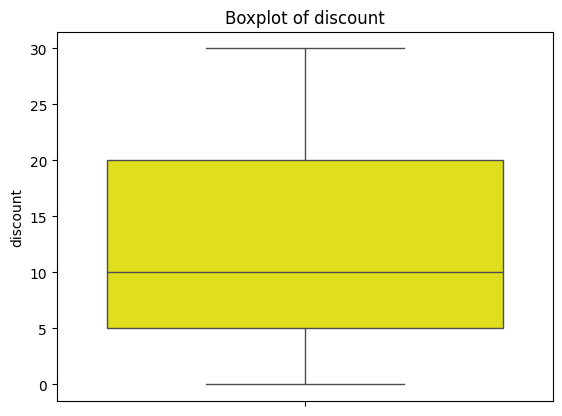

In [ ]:
sns.boxplot(df["discount"],color="yellow") # Box Plot View of discount column
plt.title("Boxplot of discount")
plt.show()


From the above mentioned boxplot,the data points above 20 ie Discount value from the range of 21 to 30 falls in outliers

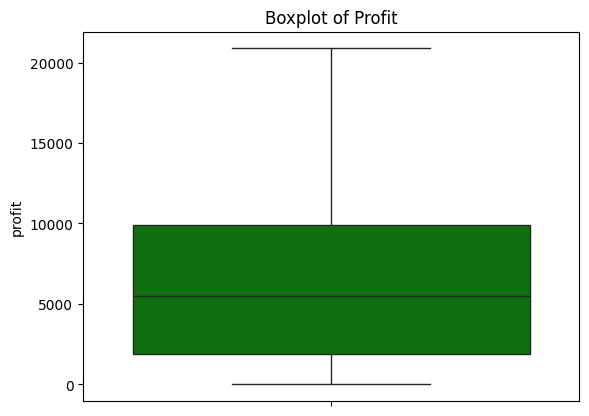

In [ ]:
sns.boxplot(df["profit"],color="green") # Box Plot View of profit column
plt.title("Boxplot of Profit")
plt.show()


From,the above mentioned boxplot of Profit,the data point above 10000 ie datapoints in the range of 10050 to 20000 falls under outliers

Q19)Write 5 key Business Insights

Business Insights

1)South Region has the highest number of Sales.The total number of Sales of South Region is 6473762.South Region contributes to 25.14% of Sales

2)There is a negative trendline of Sales value of upcoming months.

3)The Total Profit of Electronics Category is 1498228.Electronics category contributes to 31.4% of Profit

4)There is a weak positive correlation between quantity and sales of 0.027 and there is a strong negative correlation  between discount and sales of -0.69

5)Higher discount reduces the profit.From the above mentioned bar graph and correlation matrix,it is clear that there is a slightly negative correlation between discount and profit.When there is no discount or profit value is 0 then profit values are in the range of 1194 to 2000,but when discount value is 30 then there is zero profit

Q20)Give some Business Recommendations

Ans20) Some of the Business Recommendations are listed below:

a) Company must focus on North Region for increasing Sales.North Region contributes to only 21.44% of Overall Sales.

b) Higher discount reduces the profit.Hence,company must optimize the discount amount in order to increase the profit.When the discount values are in the range of 5 to 10,then profit values are also optimized

c)The Company must focus on Furniture Category for increasing sales.Furniture Category contributes to only 26.7% of overall Sales

d)There is a negative trendline of sales for upcoming months.Company must identify the root cause of negative sales trend and can perform market analysis,competitor analysis and improved market campaigns for increasing the sales of products

e) Company can also run some customer loyality program for identifying the high value customers for improving the retention rate of customers
